## Data Loading


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# load dataset
df = pd.read_csv("titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Problem 1: Subset columns and filter first class passengers

In [2]:
subset_df = df[['Name','Pclass','Sex','Age','Fare','Survived']]

# filter first class passengers
first_class = subset_df[subset_df['Pclass'] == 1]

# statistics of Fare
mean_fare = first_class['Fare'].mean()
median_fare = first_class['Fare'].median()
max_fare = first_class['Fare'].max()
min_fare = first_class['Fare'].min()

print("Mean Fare:", mean_fare)
print("Median Fare:", median_fare)
print("Max Fare:", max_fare)
print("Min Fare:", min_fare)

Mean Fare: 84.1546875
Median Fare: 60.287499999999994
Max Fare: 512.3292
Min Fare: 0.0


## Problem 2: Count and remove null values in Age

In [3]:
null_age = subset_df['Age'].isnull().sum()
print("Number of null values in Age:", null_age)

# drop null values
subset_df = subset_df.dropna(subset=['Age'])

subset_df.head()

Number of null values in Age: 177


,Name,Pclass,Sex,Age,Fare,Survived
0,"Braund, Mr. Owen Harris",3,male,22.0,7.2500,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,71.2833,1
2,"Heikkinen, Miss. Laina",3,female,26.0,7.9250,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,53.1000,1
4,"Allen, Mr. William Henry",3,male,35.0,8.0500,0


## Problem 3: One-Hot Encoding for Embarked

In [4]:
# create dummy variables
embarked_dummies = pd.get_dummies(df['Embarked'], prefix='Embarked')

# add to original dataframe
df = pd.concat([df, embarked_dummies], axis=1)

# drop original column
df = df.drop('Embarked', axis=1)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,False,False,True


## Problem 4: Survival Rate by Gender

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


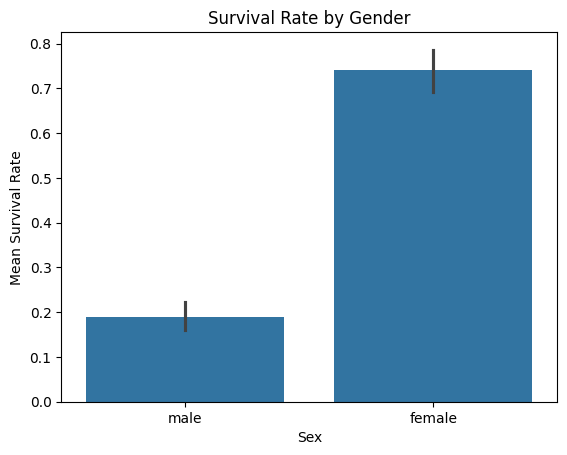

In [5]:
survival_by_sex = df.groupby('Sex')['Survived'].mean()
print(survival_by_sex)

# visualization
sns.barplot(x='Sex', y='Survived', data=df)

plt.title("Survival Rate by Gender")
plt.ylabel("Mean Survival Rate")
plt.show()

## Problem 5: Survival by Gender and Port of Embarkation

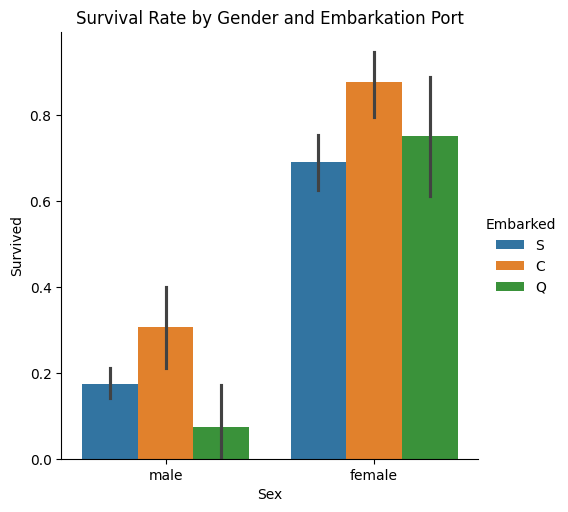

In [6]:
sns.catplot(
    x="Sex",
    y="Survived",
    hue="Embarked",
    kind="bar",
    data=pd.read_csv("titanic.csv")
)

plt.title("Survival Rate by Gender and Embarkation Port")
plt.show()

## Problem 6: Survival by Age Group and Passenger Class

C:\Users\prabe\AppData\Local\Temp\ipykernel_2500\4099447480.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_class_survival = df.groupby(['AgeGroup','Pclass'])['Survived'].mean().unstack()


Pclass                1         2         3
AgeGroup                                   
(0.419, 19.0]  0.809524  0.742857  0.333333
(19.0, 25.0]   0.761905  0.400000  0.197674
(25.0, 31.8]   0.666667  0.416667  0.283582
(31.8, 41.0]   0.777778  0.461538  0.166667
(41.0, 80.0]   0.506667  0.363636  0.088235


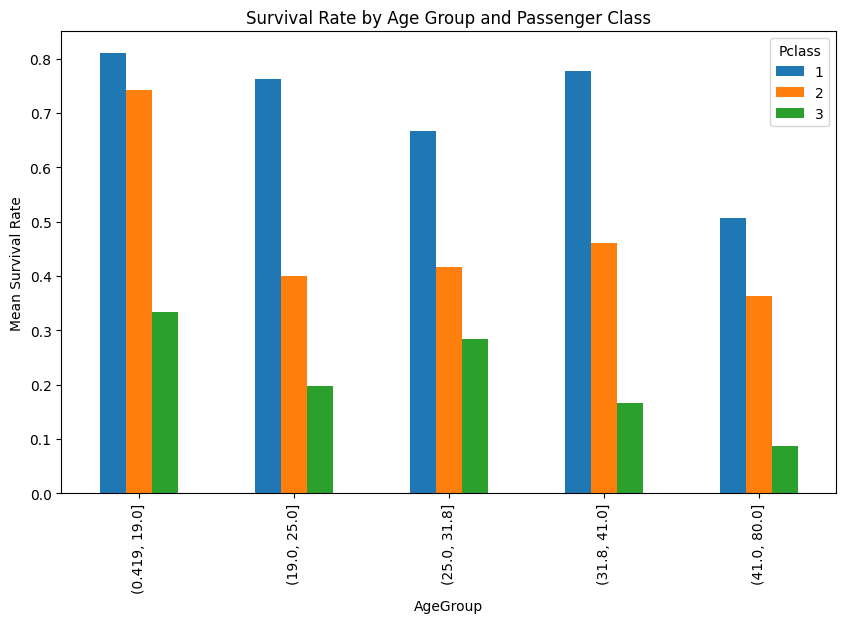

In [7]:
# divide age into 5 quantiles
df['AgeGroup'] = pd.qcut(df['Age'], 5)

# compute mean survival
age_class_survival = df.groupby(['AgeGroup','Pclass'])['Survived'].mean().unstack()

print(age_class_survival)

# visualization
age_class_survival.plot(kind='bar', figsize=(10,6))

plt.title("Survival Rate by Age Group and Passenger Class")
plt.ylabel("Mean Survival Rate")
plt.show()

# 4.2 Multivariate Analysis
## Problem 1 – Scatter Plot (Age vs Fare)

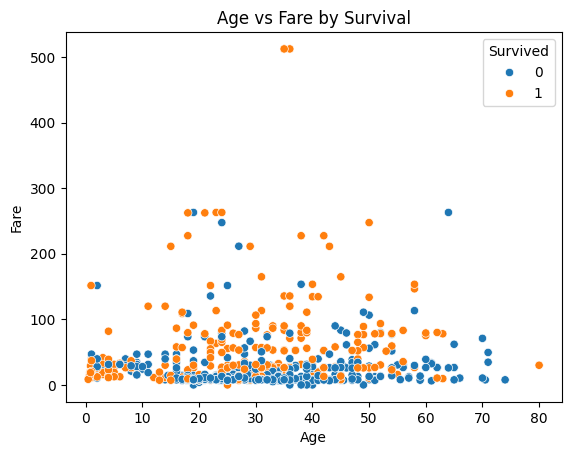

In [8]:
sns.scatterplot(
    x='Age',
    y='Fare',
    hue='Survived',
    data=df
)

plt.title("Age vs Fare by Survival")
plt.show()

## Problem 2: Pair Plot

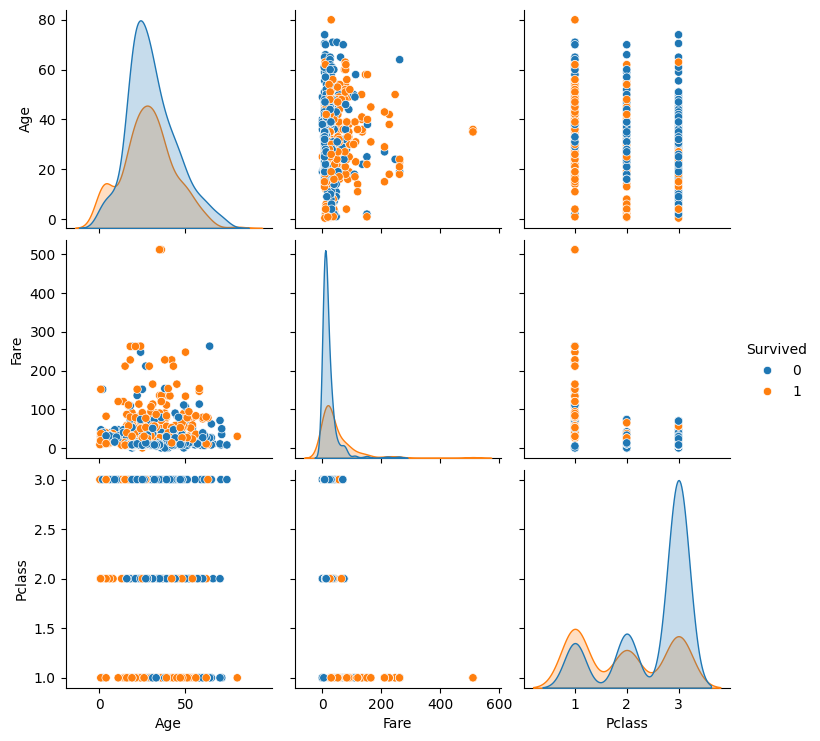

In [9]:
sns.pairplot(
    df[['Age','Fare','Pclass','Survived']],
    hue='Survived'
)

plt.show()

## Problem 3: Covariance / Correlation Heatmap

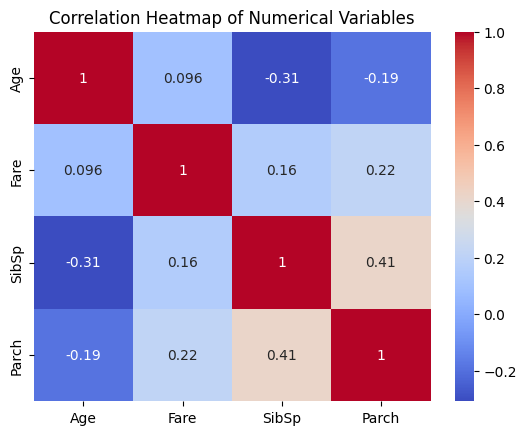

In [10]:
corr_matrix = df[['Age','Fare','SibSp','Parch']].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()